# Importar librerías

In [1]:
import sys
from pathlib import Path

# encontrar raíz del proyecto (carpeta que contiene "src")
root = Path().resolve()
while not (root / "src").exists():
    root = root.parent

sys.path.append(str(root))

In [2]:
import pandas as pd
from src.data.load_data import cargar_csv
from src.data.clean_preprocess_data import detectar_outliers, outliers_a_dataframe, winsorize_iqr
from src.data.eda_data import *

# Cargar base de datos

In [3]:
ruta_archivo = '../databases/processed/base_limpia_procesada.csv'

In [4]:
archivo = cargar_csv(ruta_archivo)
archivo.head()

,customer_id,full_name,email,phone,signup_date,last_purchase_date,monthly_spend,total_shipments,churn_label,home_address
0,C001,Juan Perez,jperez@email.com,555-0101,2023-01-15,2025-12-05,450.5,12,0,Calle Falsa 123
1,C002,Maria Garcia,m.garcia@provider.net,555-0102,2023-02-20,2025-05-10,1200.0,45,0,Carrera 7 # 45-10
2,C003,Carlos Rodriguez,c.rod@work.com,NaN,2023-03-05,2025-03-25,3435.0,8,1,Av. Siempre Viva 742
3,C004,Ana Martinez,ana.mtz@mail.com,555-0104,2023-04-12,2025-06-01,890.2,22,0,Clle 100 # 15
4,C005,Luis Herrera,lherrera@domain.org,555-0105,2023-05-30,2024-12-20,310.0,5,1,Apt 502 Torre B


In [5]:
archivo['signup_date'] = pd.to_datetime(archivo['signup_date'], format='%Y-%m-%d')
archivo['last_purchase_date'] = pd.to_datetime(archivo['last_purchase_date'], format='%Y-%m-%d')

# Análisis descriptivo

In [6]:
perfil_dataset(archivo) #se tienen variables en formato fecha, entero y flotante. Además, home_address tiene valores nulos, así como
#phone y last_purchase_date

,dtype,n_unique,n_nulls,pct_nulls,sample_values
home_address,str,95,7,6.422018,"[Calle Falsa 123, Carrera 7 # 45-10, Av. Siemp..."
phone,str,108,1,0.917431,"[555-0101, 555-0102, 555-0104]"
last_purchase_date,datetime64[us],43,1,0.917431,"[2025-12-05 00:00:00, 2025-05-10 00:00:00, 202..."
customer_id,str,109,0,0.000000,"[C001, C002, C003]"
full_name,str,109,0,0.000000,"[Juan Perez, Maria Garcia, Carlos Rodriguez]"
email,str,109,0,0.000000,"[jperez@email.com, m.garcia@provider.net, c.ro..."
signup_date,datetime64[us],95,0,0.000000,"[2023-01-15 00:00:00, 2023-02-20 00:00:00, 202..."
monthly_spend,float64,53,0,0.000000,"[450.5, 1200.0, 3435.0]"
total_shipments,int64,39,0,0.000000,"[12, 45, 8]"
churn_label,int64,2,0,0.000000,"[0, 1]"


In [7]:
# archivo = archivo[~archivo['last_purchase_date'].isna()] # se elimina la fila que tiene nulo en last_purchase_date

In [8]:
archivo[['signup_date', 'last_purchase_date', 'monthly_spend', 'total_shipments', 'churn_label']].head()

,signup_date,last_purchase_date,monthly_spend,total_shipments,churn_label
0,2023-01-15,2025-12-05,450.5,12,0
1,2023-02-20,2025-05-10,1200.0,45,0
2,2023-03-05,2025-03-25,3435.0,8,1
3,2023-04-12,2025-06-01,890.2,22,0
4,2023-05-30,2024-12-20,310.0,5,1


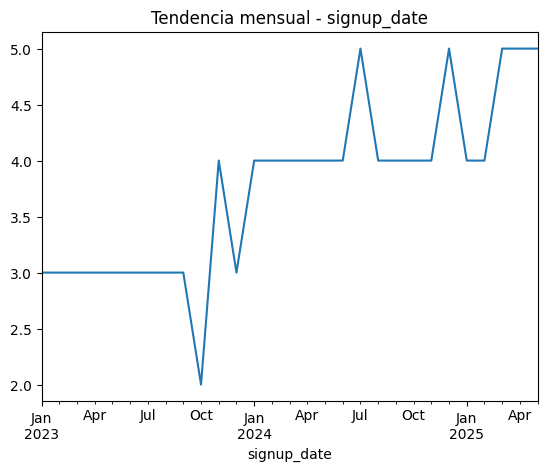

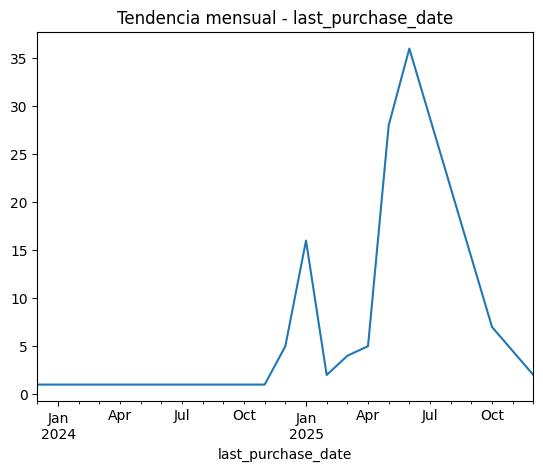

In [9]:
eda_datetime(archivo, ['signup_date', 'last_purchase_date'])

In [10]:
archivo = crear_variables_temporales(archivo)

In [11]:
archivo.info()

<class 'pandas.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   customer_id               109 non-null    str           
 1   full_name                 109 non-null    str           
 2   email                     109 non-null    str           
 3   phone                     108 non-null    str           
 4   signup_date               109 non-null    datetime64[us]
 5   last_purchase_date        108 non-null    datetime64[us]
 6   monthly_spend             109 non-null    float64       
 7   total_shipments           109 non-null    int64         
 8   churn_label               109 non-null    int64         
 9   home_address              102 non-null    str           
 10  signup_date_year          109 non-null    int32         
 11  signup_date_month         109 non-null    int32         
 12  last_purchase_date_year   108 non

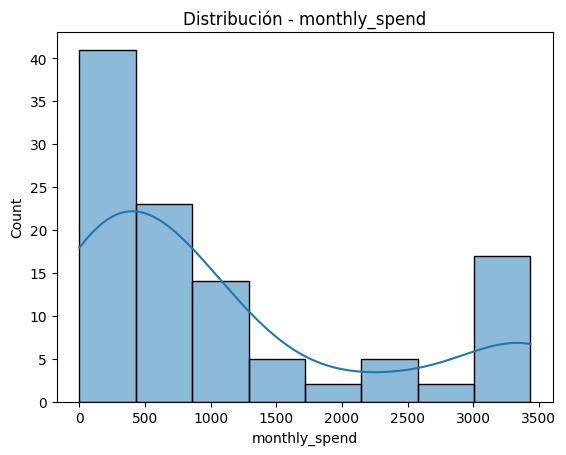

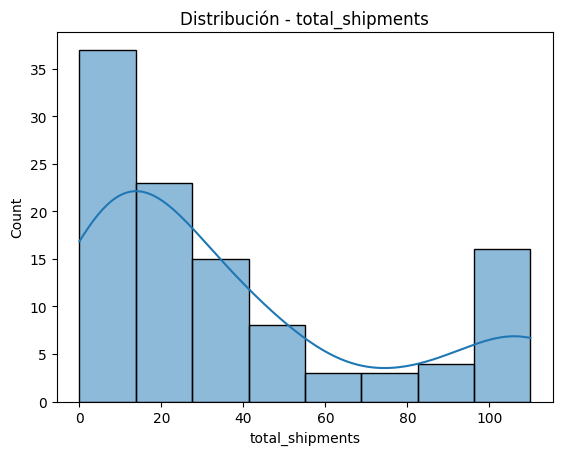

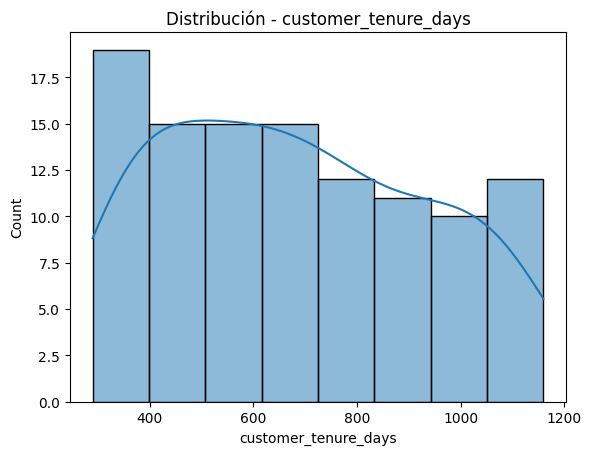

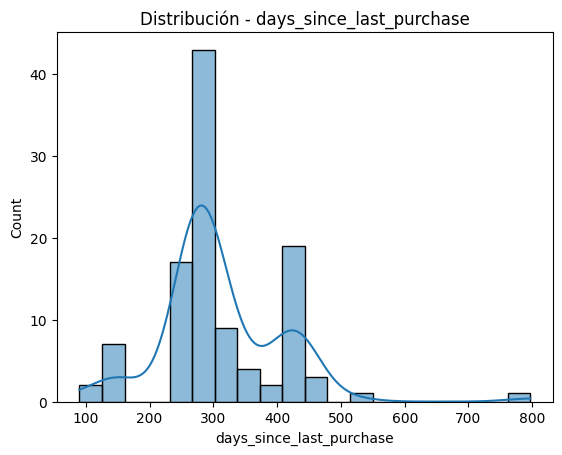

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
monthly_spend,109.0,1106.756422,1184.255768,0.0,210.0,615.0,1500.00,3435.0,1.062007,-0.324967
total_shipments,109.0,37.018349,36.901265,0.0,10.0,22.0,50.00,110.0,1.030762,-0.344895
customer_tenure_days,109.0,680.954128,252.719702,290.0,460.0,655.0,887.00,1160.0,0.229394,-1.108914
days_since_last_purchase,108.0,311.055556,94.984488,90.0,267.0,286.5,352.25,797.0,1.207381,5.617770


In [12]:
eda_numerico(archivo, ['monthly_spend', 'total_shipments', 'customer_tenure_days', 'days_since_last_purchase'])

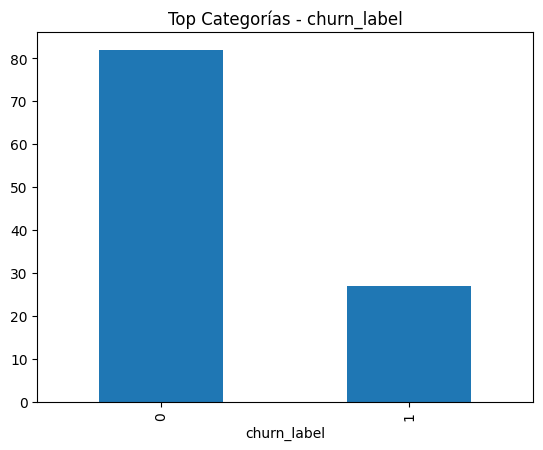

{'churn_label': churn_label
 0    82
 1    27
 Name: count, dtype: int64}

In [13]:
eda_categorico(archivo, ['churn_label'])

# Análisis descriptivo por Churn

In [14]:
churn_resumen(archivo)

,churn_label,count,mean,std,min,25%,50%,75%,max,feature
0,0,82.0,1378.432317,1197.626786,0.0,505.00,900.0,2425.00,3435.0,monthly_spend
1,1,27.0,281.666667,646.102219,0.0,0.00,150.0,310.00,3435.0,monthly_spend
2,0,82.0,47.573171,36.815198,0.0,18.25,33.5,80.00,110.0,total_shipments
3,1,27.0,4.962963,3.927041,0.0,2.00,5.0,8.00,15.0,total_shipments
4,0,82.0,651.036585,242.178765,290.0,457.00,626.5,833.25,1146.0,customer_tenure_days
5,1,27.0,771.814815,266.795087,309.0,564.50,791.0,988.50,1160.0,customer_tenure_days
6,0,82.0,281.170732,70.066953,90.0,264.00,278.0,295.00,425.0,days_since_last_purchase
7,1,26.0,405.307692,102.663633,269.0,346.00,420.0,438.25,797.0,days_since_last_purchase


In [15]:
churn_analisis_temporal(archivo)

,signup_month,churn_label
0,2023-01,0.666667
1,2023-02,0.333333
2,2023-03,0.333333
3,2023-04,0.000000
4,2023-05,0.666667
5,2023-06,0.333333
6,2023-07,1.000000
7,2023-08,0.333333
8,2023-09,0.333333
9,2023-10,0.000000


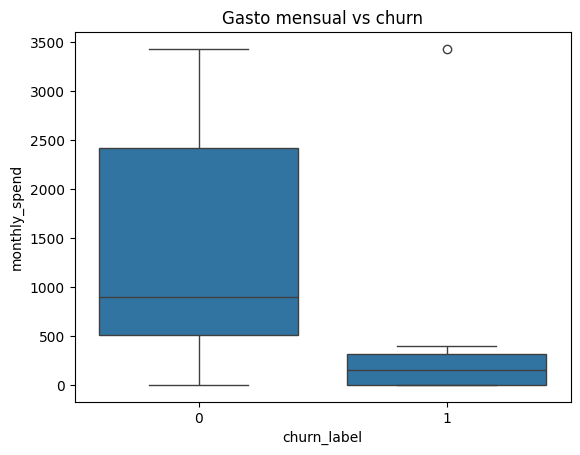

In [16]:
grafico_gasto_vs_churn(archivo)

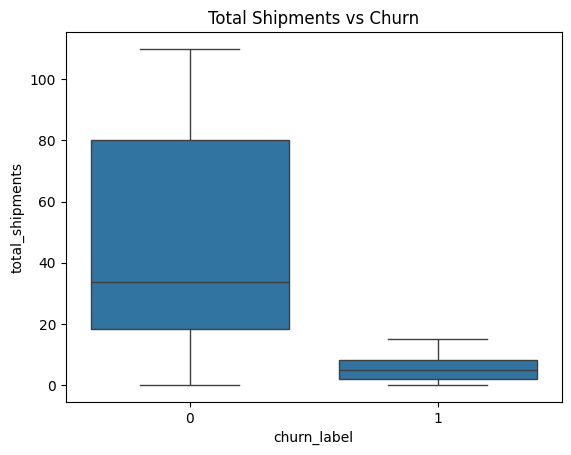

In [17]:
grafico_shipments_vs_churn(archivo)

In [18]:
preparar_series_de_tiempo(archivo)

,month,churn_label,monthly_spend,total_shipments
0,2023-12-01,1,100.000000,2.000000
1,2024-10-01,1,200.000000,2.000000
2,2024-11-01,1,210.000000,5.000000
3,2024-12-01,1,182.000000,4.800000
4,2025-01-01,0,1442.861111,50.333333
5,2025-01-01,1,71.428571,4.000000
6,2025-02-01,1,370.000000,9.000000
7,2025-03-01,0,1500.000000,60.000000
8,2025-03-01,1,1248.333333,9.666667
9,2025-04-01,0,700.000000,5.500000


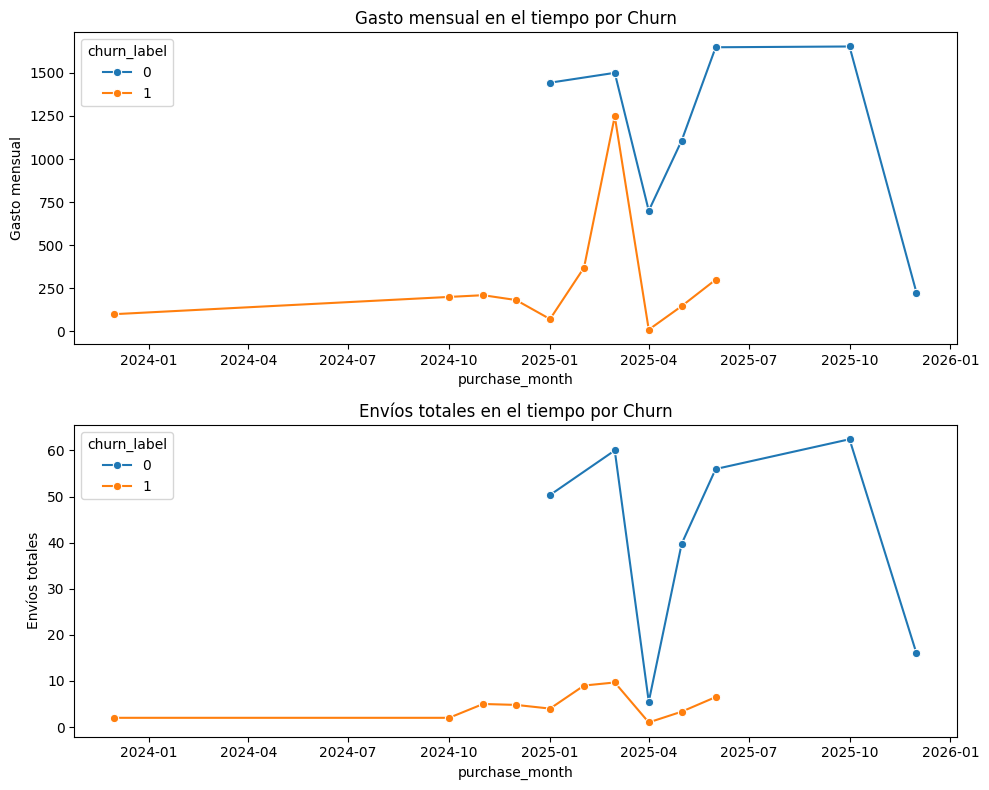

In [19]:
grafico_series_tiempo_multivariada(archivo)

# Análisis de outliers

In [20]:
features = ["monthly_spend","total_shipments","customer_tenure_days","days_since_last_purchase"]
# Detectar outliers con IQR
outliers_iqr = outliers_a_dataframe(detectar_outliers(archivo, features, metodo="IQR"))
# Ver outliers de monthly_spend
outliers_iqr

,index,customer_id,feature,value
0,0,C001,days_since_last_purchase,91.0
1,54,C056,days_since_last_purchase,517.0
2,80,C082,days_since_last_purchase,797.0
3,96,C098,days_since_last_purchase,90.0


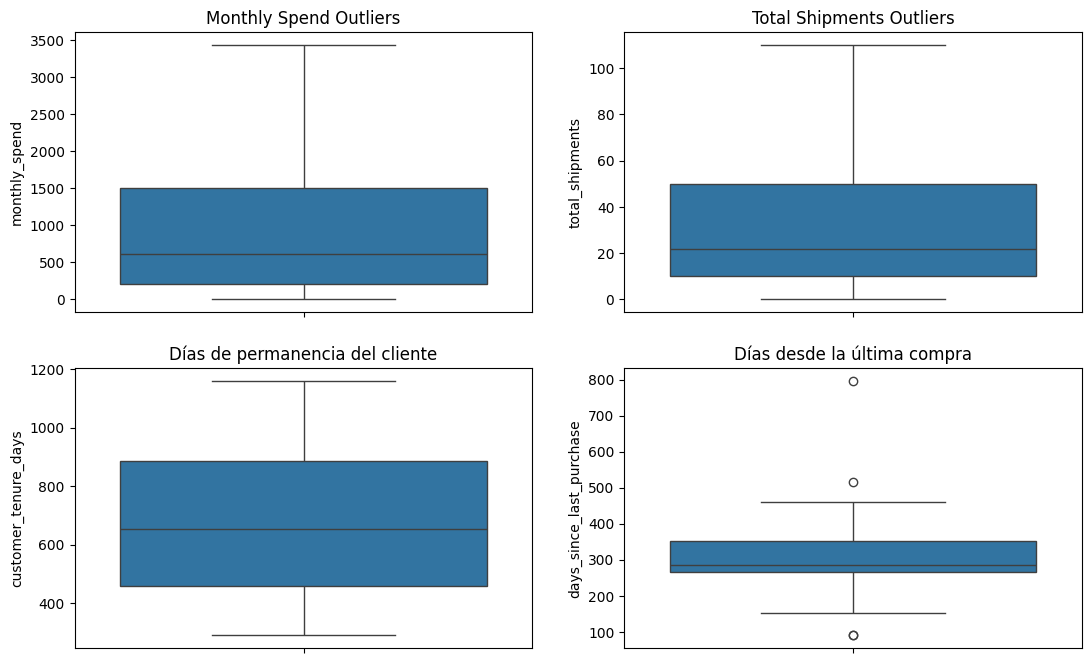

In [21]:
graficar_outliers(archivo)

In [22]:
archivo = winsorize_iqr(archivo, "days_since_last_purchase")

# Análisis de correlación

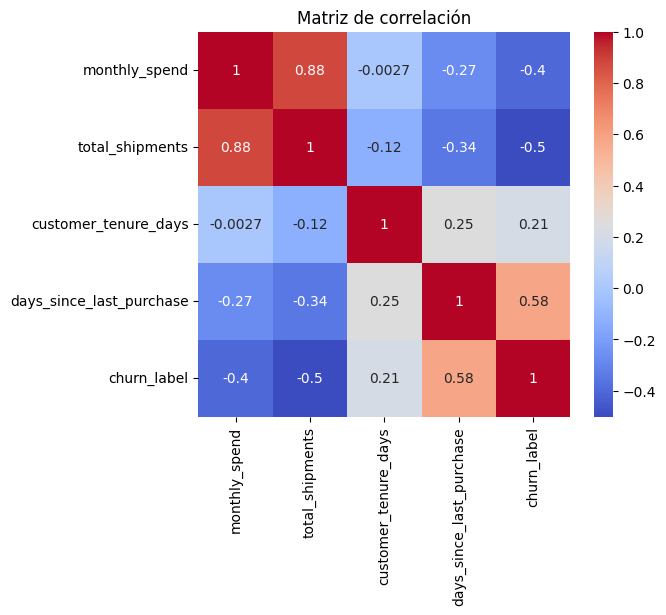

In [23]:
matriz_correlacion(archivo)

In [24]:
churn_correlacion_numerica(archivo)

,correlation,p_value,n
monthly_spend,-0.401635,1.500837e-05,109.0
total_shipments,-0.500767,2.933429e-08,109.0
customer_tenure_days,0.207259,3.058439e-02,109.0
days_since_last_purchase,0.578532,5.473268e-11,108.0


# Análisis de ciclo de vida del cliente

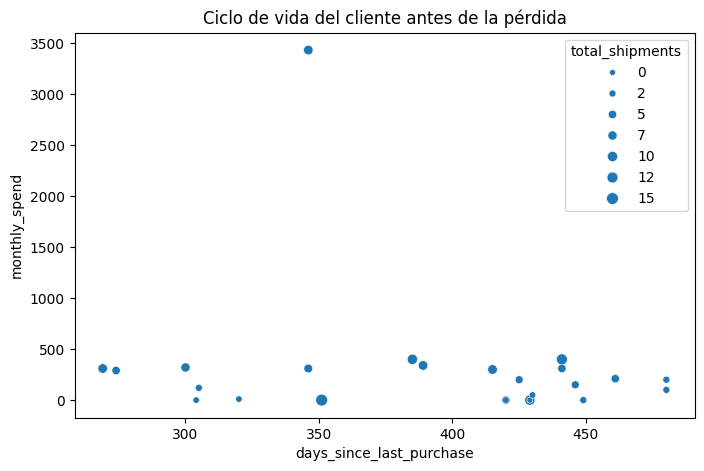

In [25]:
lifecycle_analysis(archivo)

# Seleccionar variables y exportar

In [26]:
archivo = archivo[['customer_id','churn_label', 'signup_date', 'last_purchase_date', 'monthly_spend', 'total_shipments',
                   'signup_date_year', 'signup_date_month', 'last_purchase_date_year', 'last_purchase_date_month',
                   'customer_tenure_days', 'days_since_last_purchase', 'signup_month', 'purchase_month']]

In [27]:
archivo.to_csv('../databases/processed/base_limpia_procesada.csv', sep=',', index=False)